# 03 — Battery MPC Optimizer: Walkthrough & Backtest Results

This notebook has two purposes:

1. **Explain how the MPC optimizer works**, step by step, starting from a single-hour
   dispatch decision all the way up to the full annual backtest.
2. **Visualise the 2025 backtest results** for all three strategies: Model MPC,
   Naive rule-based, and Perfect Foresight.

The optimizer is a **Model Predictive Control (MPC)** loop powered by a Linear Programme
(LP) solved with PuLP + CBC. At each hour it looks 24 hours ahead, finds the optimal
charge/discharge schedule for the battery, applies only the *first* decision, then
repeats at the next hour.

The backtest was already run and saved to `Optimization/results/backtest_2025.csv`.

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from IPython.display import display
import numpy as np
import pandas as pd
from pathlib import Path
import sys

project_root = Path().resolve().parent.parent
sys.path.insert(0, str(project_root / "src"))

from optimizer import (
    solve_dispatch,
    CAPACITY_KWH, MAX_POWER_KW, SOC_MIN_KWH, SOC_MAX_KWH,
    CHARGE_EFF, DISCHARGE_EFF, GRID_IMPORT_LIMIT_KWH, DEGRADATION_COST_EUR_KWH,
)

RESULTS_DIR = project_root / "Optimization" / "results"
PLOTS_DIR   = project_root / "Analytics" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# Load backtest results
results = pd.read_csv(
    RESULTS_DIR / "backtest_2025.csv",
    index_col=0, parse_dates=True,
)

print(f"Shape      : {results.shape}")
print(f"Columns    : {results.columns.tolist()}")
print(f"Date range : {results.index.min()} → {results.index.max()}")
print()
results.head()

Shape      : (8759, 21)
Columns    : ['actual_price', 'forecast_price', 'consumption_kwh', 'soc_model', 'charge_model', 'discharge_model', 'grid_import_model', 'grid_export_model', 'revenue_model', 'soc_naive', 'charge_naive', 'discharge_naive', 'grid_import_naive', 'grid_export_naive', 'revenue_naive', 'soc_perfect', 'charge_perfect', 'discharge_perfect', 'grid_import_perfect', 'grid_export_perfect', 'revenue_perfect']
Date range : 2025-01-01 00:00:00+00:00 → 2025-12-31 22:00:00+00:00



,actual_price,forecast_price,consumption_kwh,soc_model,charge_model,discharge_model,grid_import_model,grid_export_model,revenue_model,soc_naive,...,discharge_naive,grid_import_naive,grid_export_naive,revenue_naive,soc_perfect,charge_perfect,discharge_perfect,grid_import_perfect,grid_export_perfect,revenue_perfect
datetime,,,,,,,,,,,,,,,,,,,,,
2025-01-01 00:00:00+00:00,0.00624,0.007389,48.6,500.000000,0.0000,0.0,48.6000,0.0,0.000000,500.00000,...,0.0,48.600000,0.0,0.000000,100.00000,0.0,379.48,0.0,330.88,2.367955
2025-01-01 01:00:00+00:00,0.00416,0.006931,43.5,612.638772,118.7296,0.0,162.2296,0.0,-0.493915,500.00000,...,0.0,43.500000,0.0,0.000000,100.00000,0.0,0.00,43.5,0.00,0.000000
2025-01-01 02:00:00+00:00,0.00328,0.005142,47.1,900.000000,302.9000,0.0,350.0000,0.0,-0.993512,787.36123,...,0.0,350.000000,0.0,-0.993512,100.00000,0.0,0.00,47.1,0.00,0.000000
2025-01-01 03:00:00+00:00,0.00068,0.007680,48.3,900.000000,0.0000,0.0,48.3000,0.0,0.000000,900.00000,...,0.0,167.029598,0.0,-0.080736,386.22279,301.7,0.00,350.0,0.00,-0.205156
2025-01-01 04:00:00+00:00,0.00000,0.007763,51.3,900.000000,0.0000,0.0,51.3000,0.0,0.000000,900.00000,...,0.0,51.300000,0.0,0.000000,669.59948,298.7,0.00,350.0,0.00,-0.000000


## Section 2 — Battery and System Parameters

The battery and grid connection are modelled with these constants:

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Capacity | 1,000 kWh | Standard commercial BESS size (1 MWh) |
| Max power | 500 kW | 0.5C rate — common for grid-connected storage |
| SOC min | 100 kWh (10%) | Protects cell chemistry from deep discharge |
| SOC max | 900 kWh (90%) | Protects from overcharge, extends cycle life |
| Round-trip efficiency | 90% | Industry-standard lithium-ion value |
| Charge efficiency | √0.90 ≈ 94.87% | Split symmetrically across charge and discharge |
| Discharge efficiency | √0.90 ≈ 94.87% | Same — losses apply in both directions |
| Grid import limit | 350 kWh/h | Connection capacity constraint |
| Degradation cost | 0.0001 EUR/kWh | Small penalty to prevent unnecessary cycling |

**System topology:**

```
         Grid
           │
    ≤ 350 kWh/h
           │
     ┌─────┴─────┐
     │           │
  Battery     Building
 1 MWh, 500kW  Consumption
  10–90% SOC   32–328 kWh/h
```

The **energy balance** at every hour:

```
grid_import + discharge = consumption + charge + grid_export
```

The **SOC update** rule:

```
SOC[t+1] = SOC[t] + charge[t] × η_c  −  discharge[t] / η_d
```

where `η_c = η_d = √0.90 ≈ 0.9487`.  Charging stores only a fraction of the input
energy; discharging must draw more from the battery than is delivered to the load.

In [2]:
params = [
    ("CAPACITY_KWH",           CAPACITY_KWH,           "kWh",    "Battery energy capacity"),
    ("MAX_POWER_KW",            MAX_POWER_KW,            "kW",     "Max charge / discharge rate (0.5 C)"),
    ("SOC_MIN_KWH",             SOC_MIN_KWH,             "kWh",    "Minimum state of charge (10%)"),
    ("SOC_MAX_KWH",             SOC_MAX_KWH,             "kWh",    "Maximum state of charge (90%)"),
    ("CHARGE_EFF",              CHARGE_EFF,              "—",      "One-way charge efficiency (√0.90)"),
    ("DISCHARGE_EFF",           DISCHARGE_EFF,           "—",      "One-way discharge efficiency (√0.90)"),
    ("GRID_IMPORT_LIMIT_KWH",   GRID_IMPORT_LIMIT_KWH,   "kWh/h",  "Maximum grid import per hour"),
    ("DEGRADATION_COST_EUR_KWH",DEGRADATION_COST_EUR_KWH,"EUR/kWh","Cycling cost to prevent over-cycling"),
]

header = f"{'Parameter':<30} {'Value':>10} {'Unit':<8} Description"
print(header)
print("─" * len(header))
for name, val, unit, desc in params:
    print(f"{name:<30} {val:>10.4f} {unit:<8} {desc}")

Parameter                           Value Unit     Description
──────────────────────────────────────────────────────────────
CAPACITY_KWH                    1000.0000 kWh      Battery energy capacity
MAX_POWER_KW                     500.0000 kW       Max charge / discharge rate (0.5 C)
SOC_MIN_KWH                      100.0000 kWh      Minimum state of charge (10%)
SOC_MAX_KWH                      900.0000 kWh      Maximum state of charge (90%)
CHARGE_EFF                         0.9487 —        One-way charge efficiency (√0.90)
DISCHARGE_EFF                      0.9487 —        One-way discharge efficiency (√0.90)
GRID_IMPORT_LIMIT_KWH            350.0000 kWh/h    Maximum grid import per hour
DEGRADATION_COST_EUR_KWH           0.0001 EUR/kWh  Cycling cost to prevent over-cycling


## Section 3 — How the LP Optimizer Works (Single-Hour Walkthrough)

### Model Predictive Control in plain language

At **each hour** the optimizer does the following:

1. **Look ahead 24 hours** using the LightGBM price forecast.
2. **Solve a linear programme** that finds the sequence of charge/discharge decisions
   that maximises profit over the 24-hour horizon, subject to battery and grid constraints.
3. **Apply only the first hour's decision** (charge or discharge by some amount).
4. **Advance the clock** by one hour and repeat.

This "receding horizon" approach means the battery always benefits from 24 hours of
look-ahead, but decisions are made one hour at a time as reality unfolds.

### The objective function

Maximise:  `Σ (grid_export[t] − grid_import[t]) × price[t]  −  degradation × (charge[t] + discharge[t])`

This is equivalent to maximising **savings vs paying market price for all consumption**,
because `grid_export − grid_import = discharge − charge − consumption` (constant).

### Constraints at every hour t

- Energy balance: `grid_import[t] + discharge[t] = consumption[t] + charge[t] + grid_export[t]`
- SOC bounds: `100 ≤ SOC[t] ≤ 900`
- Power limits: `0 ≤ charge[t] ≤ 500`, `0 ≤ discharge[t] ≤ 500`
- Grid limit: `0 ≤ grid_import[t] ≤ 350`
- Non-negativity: `grid_export[t] ≥ 0`

---

Below we walk through **one specific hour: 2025-01-15 08:00 UTC**.
We extract the same inputs that the backtest used, re-run the LP, and print the full
24-hour plan it produced.

In [3]:
target  = pd.Timestamp("2025-01-15 08:00", tz="UTC")
prev    = pd.Timestamp("2025-01-15 07:00", tz="UTC")

# SOC at the *start* of target hour = SOC at end of the previous hour
current_soc = float(results.loc[prev, "soc_model"])
print(f"SOC at start of {target}: {current_soc:.1f} kWh")

# 24-hour look-ahead window of forecast prices and consumption
window   = results.loc[target:].iloc[:24]
p_fc     = window["forecast_price"].values.astype(float)
cons_24h = window["consumption_kwh"].values.astype(float)

# Solve the LP
plan = solve_dispatch(p_fc, cons_24h, current_soc)

# Display the 24-hour plan
print()
print(f"{'Hr':>3} {'Time (UTC)':>14} {'Price fc':>9} {'Cons':>7} "
      f"{'Charge':>7} {'Disch':>7} {'Import':>7} {'Export':>7} {'SOC →':>7}")
print("─" * 75)
for t in range(len(p_fc)):
    dt_label = window.index[t].strftime("%m-%d %H:00")
    print(
        f"{t:>3} {dt_label:>14} {p_fc[t]:>9.4f} {cons_24h[t]:>7.1f} "
        f"{plan['charge_kwh'][t]:>7.1f} {plan['discharge_kwh'][t]:>7.1f} "
        f"{plan['grid_import_kwh'][t]:>7.1f} {plan['grid_export_kwh'][t]:>7.1f} "
        f"{plan['soc_kwh'][t+1]:>7.1f}"
    )
print("─" * 75)
print(f"Expected revenue from this 24h window: {plan['expected_revenue_eur']:.4f} EUR")

SOC at start of 2025-01-15 08:00:00+00:00: 900.0 kWh

 Hr     Time (UTC)  Price fc    Cons  Charge   Disch  Import  Export   SOC →
───────────────────────────────────────────────────────────────────────────
  0    01-15 08:00    0.2788   234.3     0.0   268.1     0.0    33.8   617.4
  1    01-15 09:00    0.2654   247.7     0.0     0.0   247.7     0.0   617.4
  2    01-15 10:00    0.2610   242.9     0.0     0.0   242.9     0.0   617.4
  3    01-15 11:00    0.2388   251.3    98.7     0.0   350.0     0.0   711.0
  4    01-15 12:00    0.2293   251.0    99.0     0.0   350.0     0.0   804.9
  5    01-15 13:00    0.2273   249.8   100.2     0.0   350.0     0.0   900.0
  6    01-15 14:00    0.2648   242.4     0.0     0.0   242.4     0.0   900.0
  7    01-15 15:00    0.2724   241.0     0.0     0.0   241.0     0.0   900.0
  8    01-15 16:00    0.3121   237.8     0.0   259.0     0.0    21.2   627.0
  9    01-15 17:00    0.3387   228.0     0.0   500.0     0.0   272.0   100.0
 10    01-15 18:00    0

## Section 4 — Single-Hour Dispatch Visualisation

The three panels below show the full 24-hour plan for 2025-01-15 08:00 UTC:

- **Top**: Forecast price bar chart. Bars are coloured green (cheap) → red (expensive)
  relative to the day's price range. The optimizer charges during cheap hours and
  discharges during expensive ones.
- **Middle**: Charge (blue, positive) and discharge (red, negative) decisions.
- **Bottom**: Resulting SOC trajectory with bounds marked.

Saved: /Users/marijacveevska/Developer/epex_battery_forecast_and_optimization/Analytics/plots/mpc_single_hour_example.png


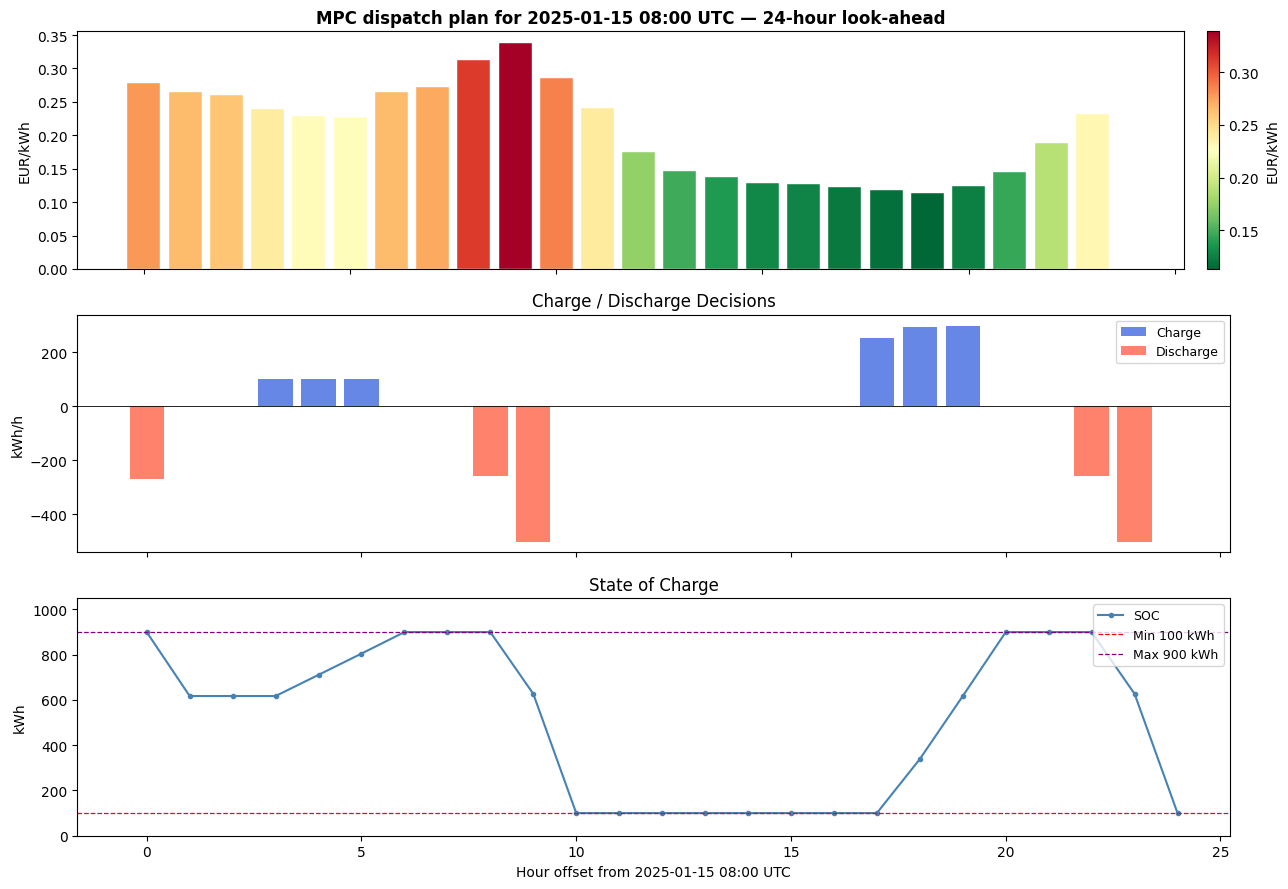

In [4]:
hours = np.arange(len(p_fc))
prices_norm = (p_fc - p_fc.min()) / (p_fc.max() - p_fc.min() + 1e-9)
colors = plt.cm.RdYlGn_r(prices_norm)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

# ── Top: forecast price ───────────────────────────────────────────────────
axes[0].bar(hours, p_fc, color=colors, edgecolor="white", linewidth=0.3)
axes[0].set_ylabel("EUR/kWh")
axes[0].set_title(
    "MPC dispatch plan for 2025-01-15 08:00 UTC — 24-hour look-ahead",
    fontsize=12, fontweight="bold",
)
sm = ScalarMappable(cmap="RdYlGn_r", norm=mcolors.Normalize(vmin=p_fc.min(), vmax=p_fc.max()))
sm.set_array([])
plt.colorbar(sm, ax=axes[0], label="EUR/kWh", fraction=0.02, pad=0.02)

# ── Middle: dispatch ─────────────────────────────────────────────────────
axes[1].bar(hours, plan["charge_kwh"], color="royalblue", label="Charge", alpha=0.8)
axes[1].bar(hours, [-d for d in plan["discharge_kwh"]], color="tomato",
            label="Discharge", alpha=0.8)
axes[1].axhline(0, color="black", lw=0.6)
axes[1].set_ylabel("kWh/h")
axes[1].set_title("Charge / Discharge Decisions")
axes[1].legend(loc="upper right", fontsize=9)

# ── Bottom: SOC trajectory ───────────────────────────────────────────────
soc_vals = plan["soc_kwh"]
axes[2].plot(range(len(soc_vals)), soc_vals, color="steelblue", marker="o",
             markersize=3, lw=1.5, label="SOC")
axes[2].axhline(SOC_MIN_KWH, color="red",    ls="--", lw=0.9, label=f"Min {SOC_MIN_KWH:.0f} kWh")
axes[2].axhline(SOC_MAX_KWH, color="purple", ls="--", lw=0.9, label=f"Max {SOC_MAX_KWH:.0f} kWh")
axes[2].set_xlabel("Hour offset from 2025-01-15 08:00 UTC")
axes[2].set_ylabel("kWh")
axes[2].set_title("State of Charge")
axes[2].legend(loc="upper right", fontsize=9)
axes[2].set_ylim(0, CAPACITY_KWH + 50)

plt.tight_layout()
out = PLOTS_DIR / "mpc_single_hour_example.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
print(f"Saved: {out}")
display(fig)
plt.close(fig)

## Section 5 — What Is Revenue and How Is It Calculated?

### Definition

**Revenue = savings vs the no-battery baseline.**

Without a battery the building imports *all* its consumption from the grid:
```
baseline_cost[t] = consumption[t] × actual_price[t]
```

With a battery the building either imports less, or exports surplus:
```
actual_net_cost[t] = (grid_import[t] − grid_export[t]) × actual_price[t]
```

Savings (= revenue):
```
revenue[t] = baseline_cost[t] − actual_net_cost[t]
           = (discharge[t] − charge[t]) × actual_price[t]
```

**Example:** consumption = 100 kWh, price = 0.10 EUR/kWh

| Scenario | discharge | charge | grid_import | revenue |
|----------|-----------|--------|-------------|---------|
| No battery | 0 | 0 | 100 | 0 (baseline) |
| Battery discharges 60 | 60 | 0 | 40 | (60−0)×0.10 = **+6 EUR** |
| Battery charges 50 | 0 | 50 | 150 | (0−50)×0.10 = **−5 EUR** |

### Why not use gross cash flows?

Using raw `(grid_export − grid_import) × price` produces large negative numbers for
every hour (because imports always dominate), making the three strategies appear
comparable only in relative terms but impossible to interpret in absolute terms.
The savings definition gives an intuitive answer: *"how much did the battery save today?"*

In [5]:
# Show revenue calculation for 5 illustrative hours
sample_hours = [
    pd.Timestamp("2025-01-15 08:00", tz="UTC"),   # high price, discharge
    pd.Timestamp("2025-01-15 02:00", tz="UTC"),   # low price, likely charge
    pd.Timestamp("2025-07-01 18:00", tz="UTC"),   # summer peak (worst miss per CLAUDE.md)
    pd.Timestamp("2025-03-15 12:00", tz="UTC"),   # spring midday (solar suppressed prices)
    pd.Timestamp("2025-09-05 19:00", tz="UTC"),   # Sep evening spike
]

cols = ["actual_price", "consumption_kwh",
        "charge_model", "discharge_model", "revenue_model"]
df_show = results.loc[sample_hours, cols].copy()
df_show["verify_revenue"] = (
    (df_show["discharge_model"] - df_show["charge_model"]) * df_show["actual_price"]
)

print(f"{'Timestamp':<26} {'Price':>8} {'Cons':>7} {'Chrg':>7} "
      f"{'Disch':>7} {'Revenue':>9} {'Verify':>9}")
print("─" * 80)
for ts, row in df_show.iterrows():
    print(
        f"{str(ts)[:19]:<26} {row['actual_price']:>8.4f} "
        f"{row['consumption_kwh']:>7.1f} {row['charge_model']:>7.1f} "
        f"{row['discharge_model']:>7.1f} {row['revenue_model']:>9.4f} "
        f"{row['verify_revenue']:>9.4f}"
    )

Timestamp                     Price    Cons    Chrg   Disch   Revenue    Verify
────────────────────────────────────────────────────────────────────────────────
2025-01-15 08:00:00          0.3067   234.3     0.0   268.1   82.2219   82.2219
2025-01-15 02:00:00          0.1060    49.2   300.8     0.0  -31.8848  -31.8848
2025-07-01 18:00:00          0.5176   251.0     0.0     0.0    0.0000    0.0000
2025-03-15 12:00:00          0.0480   142.7   207.3     0.0   -9.9499   -9.9499
2025-09-05 19:00:00          0.1163   146.2     0.0     0.0    0.0000    0.0000


## Section 6 — Three Strategies Compared

| Strategy | Description |
|----------|-------------|
| **Model MPC** | At each hour, solves a 24-step LP using LightGBM price *forecasts* as input. Applies only the t=0 decision. Represents a realistic deployable system. |
| **Naive** | Fixed rule: charge at full power during hours 02–05 UTC (cheap overnight), discharge at full power during hours 17–20 UTC (evening peak). Simple but inflexible. |
| **Perfect Foresight** | Same LP, but uses *actual* realised prices instead of forecasts. Represents the theoretical upper bound — achievable only if prices were known in advance. |

The **gap between Model MPC and Perfect Foresight** reveals the cost of forecast error.
The **gap between Naive and Model MPC** shows the value of price-aware optimization.

In [6]:
total_m = results["revenue_model"].sum()
total_n = results["revenue_naive"].sum()
total_p = results["revenue_perfect"].sum()

cycles_m = results["discharge_model"].sum() / CAPACITY_KWH
cycles_n = results["discharge_naive"].sum() / CAPACITY_KWH
cycles_p = results["discharge_perfect"].sum() / CAPACITY_KWH

n_days = len(results) / 24

pct_m = total_m / total_p * 100
pct_n = total_n / total_p * 100

print(f"{'Metric':<34} {'Model MPC':>12} {'Naive':>10} {'Perfect':>10}")
print("─" * 68)
print(f"{'Total savings (EUR)':<34} {total_m:>12.2f} {total_n:>10.2f} {total_p:>10.2f}")
print(f"{'Avg daily savings (EUR/day)':<34} {total_m/n_days:>12.2f} {total_n/n_days:>10.2f} {total_p/n_days:>10.2f}")
print(f"{'Full cycles (discharge / capacity)':<34} {cycles_m:>12.1f} {cycles_n:>10.1f} {cycles_p:>10.1f}")
print(f"{'% of perfect foresight captured':<34} {pct_m:>11.1f}% {pct_n:>9.1f}%    100.0%")
print("─" * 68)

Metric                                Model MPC      Naive    Perfect
────────────────────────────────────────────────────────────────────
Total savings (EUR)                    29995.97   11942.78   33539.26
Avg daily savings (EUR/day)               82.19      32.72      91.90
Full cycles (discharge / capacity)        564.5      276.8      526.0
% of perfect foresight captured           89.4%      35.6%    100.0%
────────────────────────────────────────────────────────────────────


## Section 7 — Full-Year Results: Cumulative Revenue

The cumulative savings chart shows the compound effect of hourly decisions over 2025.
Steep rises indicate periods of high price volatility that the battery exploits well.
Flat periods indicate low-price regimes with little arbitrage opportunity.

The daily scatter shows hour-to-hour volatility — some days generate large savings
from a single well-timed dispatch; others produce near-zero benefit.

Saved: revenue_overview_2025.png


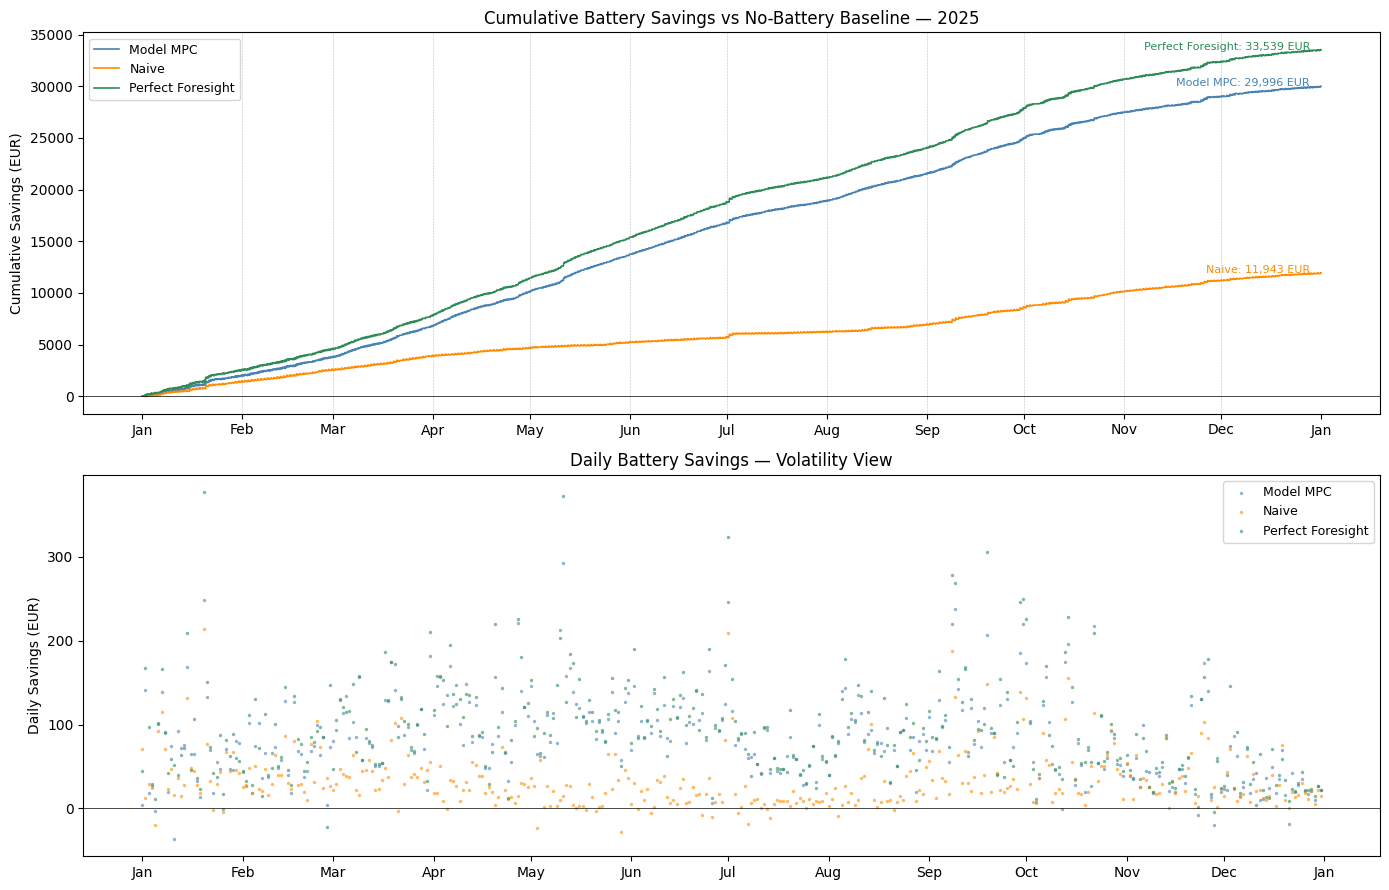

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# ── Cumulative revenue ────────────────────────────────────────────────────
ax = axes[0]
for col, label, color in [
    ("revenue_model",   "Model MPC",        "steelblue"),
    ("revenue_naive",   "Naive",            "darkorange"),
    ("revenue_perfect", "Perfect Foresight","seagreen"),
]:
    cumsum = results[col].cumsum()
    ax.plot(results.index, cumsum, label=label, color=color, lw=1.2)
    final = cumsum.iloc[-1]
    ax.annotate(
        f"{label}: {final:,.0f} EUR",
        xy=(results.index[-1], final),
        xytext=(-8, 0), textcoords="offset points",
        ha="right", fontsize=8, color=color,
    )

for month_start in pd.date_range("2025-02-01", "2025-12-01", freq="MS", tz="UTC"):
    ax.axvline(month_start, color="gray", lw=0.4, ls="--", alpha=0.5)

ax.axhline(0, color="black", lw=0.5)
ax.set_ylabel("Cumulative Savings (EUR)")
ax.set_title("Cumulative Battery Savings vs No-Battery Baseline — 2025")
ax.legend(loc="upper left", fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# ── Daily savings scatter ─────────────────────────────────────────────────
ax2 = axes[1]
daily = results[["revenue_model", "revenue_naive", "revenue_perfect"]].resample("D").sum()
for col, label, color in [
    ("revenue_model",   "Model MPC",        "steelblue"),
    ("revenue_naive",   "Naive",            "darkorange"),
    ("revenue_perfect", "Perfect Foresight","seagreen"),
]:
    ax2.scatter(daily.index, daily[col], label=label, color=color,
                s=6, alpha=0.6, linewidths=0)

ax2.axhline(0, color="black", lw=0.5)
ax2.set_ylabel("Daily Savings (EUR)")
ax2.set_title("Daily Battery Savings — Volatility View")
ax2.legend(loc="upper right", fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax2.xaxis.set_major_locator(mdates.MonthLocator())

plt.tight_layout()
for p in [PLOTS_DIR, RESULTS_DIR]:
    plt.savefig(p / "revenue_overview_2025.png", dpi=150, bbox_inches="tight")
print("Saved: revenue_overview_2025.png")
display(fig)
plt.close(fig)

## Section 8 — Monthly Breakdown

Saved: monthly_revenue_2025.png


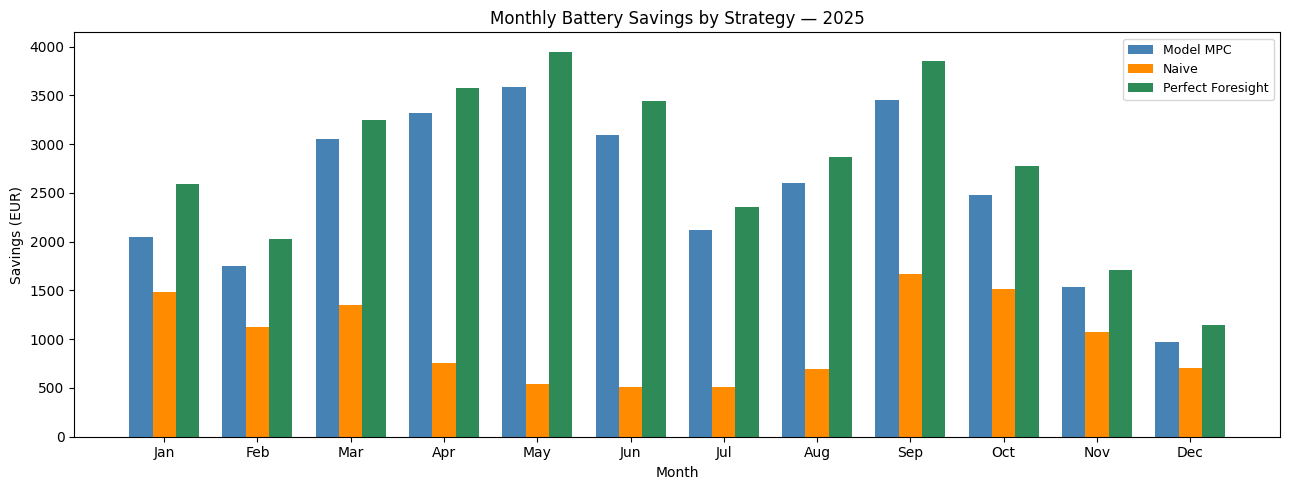


Month     Model (EUR)  Naive (EUR)  Perfect (EUR)  Efficiency %
───────────────────────────────────────────────────────────────
Jan            2048.4       1484.3         2589.1         79.1%
Feb            1748.4       1128.3         2022.7         86.4%
Mar            3048.4       1348.1         3249.6         93.8%
Apr            3317.2        760.2         3574.5         92.8%
May            3584.9        545.4         3949.5         90.8%
Jun            3093.9        505.3         3441.2         89.9%
Jul            2119.5        510.5         2359.4         89.8%
Aug            2599.8        694.4         2866.1         90.7%
Sep            3456.3       1665.3         3857.3         89.6%
Oct            2481.6       1516.7         2779.0         89.3%
Nov            1530.8       1076.4         1708.2         89.6%
Dec             966.7        707.9         1142.8         84.6%
───────────────────────────────────────────────────────────────

Best month : May 2025 (3584.9 EUR)
Wor

In [8]:
monthly = results[["revenue_model", "revenue_naive", "revenue_perfect"]].resample("ME").sum()
month_labels = [d.strftime("%b") for d in monthly.index]
x = np.arange(len(monthly))
w = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - w, monthly["revenue_model"],   w, color="steelblue",  label="Model MPC")
ax.bar(x,     monthly["revenue_naive"],   w, color="darkorange", label="Naive")
ax.bar(x + w, monthly["revenue_perfect"], w, color="seagreen",   label="Perfect Foresight")
ax.axhline(0, color="black", lw=0.5)
ax.set_xticks(x)
ax.set_xticklabels(month_labels)
ax.set_xlabel("Month")
ax.set_ylabel("Savings (EUR)")
ax.set_title("Monthly Battery Savings by Strategy — 2025")
ax.legend(fontsize=9)
plt.tight_layout()
for p in [PLOTS_DIR, RESULTS_DIR]:
    plt.savefig(p / "monthly_revenue_2025.png", dpi=150, bbox_inches="tight")
print("Saved: monthly_revenue_2025.png")
display(fig)
plt.close(fig)

# ── Monthly table ─────────────────────────────────────────────────────────
monthly["efficiency_pct"] = monthly["revenue_model"] / monthly["revenue_perfect"] * 100
print()
print(f"{'Month':<8} {'Model (EUR)':>12} {'Naive (EUR)':>12} "
      f"{'Perfect (EUR)':>14} {'Efficiency %':>13}")
print("─" * 63)
for dt, row in monthly.iterrows():
    print(
        f"{dt.strftime('%b'):<8} {row['revenue_model']:>12.1f} "
        f"{row['revenue_naive']:>12.1f} {row['revenue_perfect']:>14.1f} "
        f"{row['efficiency_pct']:>12.1f}%"
    )
print("─" * 63)
best  = monthly["revenue_model"].idxmax()
worst = monthly["revenue_model"].idxmin()
print(f"\nBest month : {best.strftime('%B %Y')} ({monthly.loc[best,'revenue_model']:.1f} EUR)")
print(f"Worst month: {worst.strftime('%B %Y')} ({monthly.loc[worst,'revenue_model']:.1f} EUR)")

### Why do savings vary so much across months?

**Best month — May (€3,585):**
Spring brings strong solar generation which regularly pushes midday prices to zero or
negative. This creates large intraday price spreads — cheap solar at noon, expensive
demand at 17:00–20:00 — that the battery can arbitrage aggressively. The LightGBM
model captures the solar-price correlation well, so forecast accuracy stays high.

**Worst month — December (€967):**
Winter has lower solar generation so intraday price swings are smaller. Prices are more
uniform across the day (dominated by gas-fired generation), leaving less spread to
exploit. Demand is also higher, which pushes consumption closer to the 350 kWh/h grid
limit, reducing charging headroom during off-peak hours.

## Section 9 — SOC Evolution

The SOC (state of charge) tells us when the battery is charging vs discharging.
A healthy cycling pattern shows:
- SOC rising overnight (cheap hours) and falling during peak-price hours.
- Perfect foresight tends to cycle more aggressively — it knows exactly when to act.
- Naive stays near extremes (90% overnight after charging window, falling after 17:00).
- Model MPC cycles more dynamically, reflecting price signal awareness.

Saved: soc_full_year_2025.png


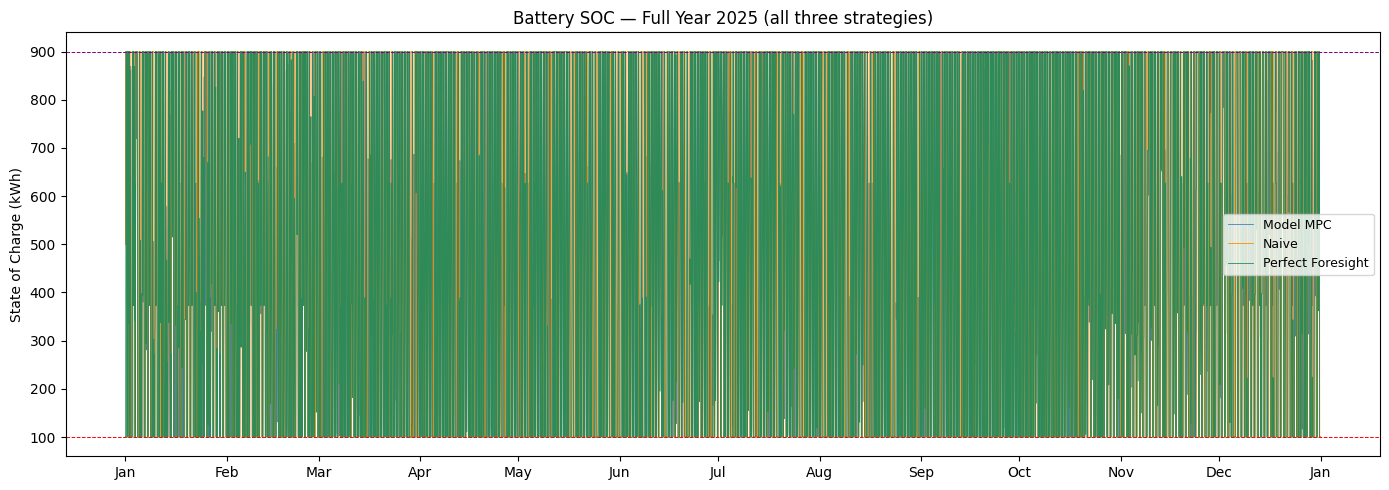

Saved: soc_zoom_january_2025.png


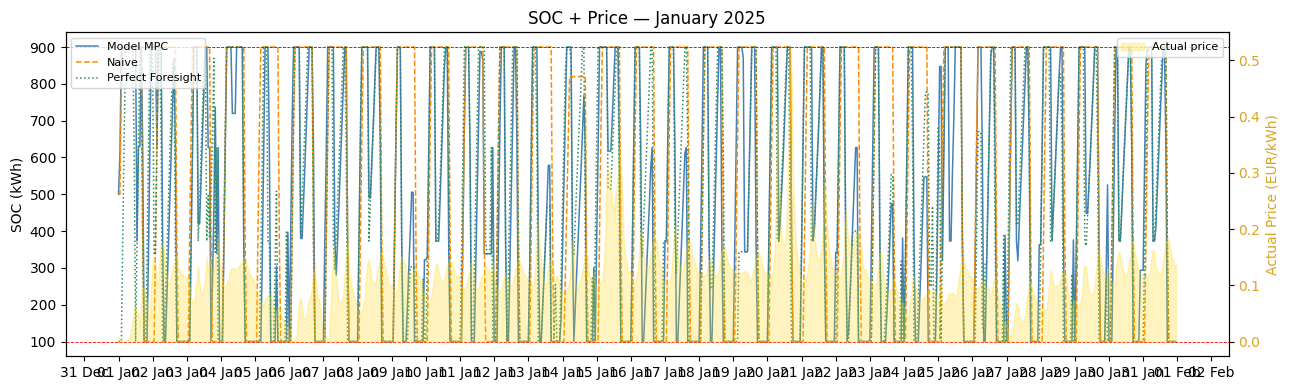

Saved: soc_zoom_july_2025.png


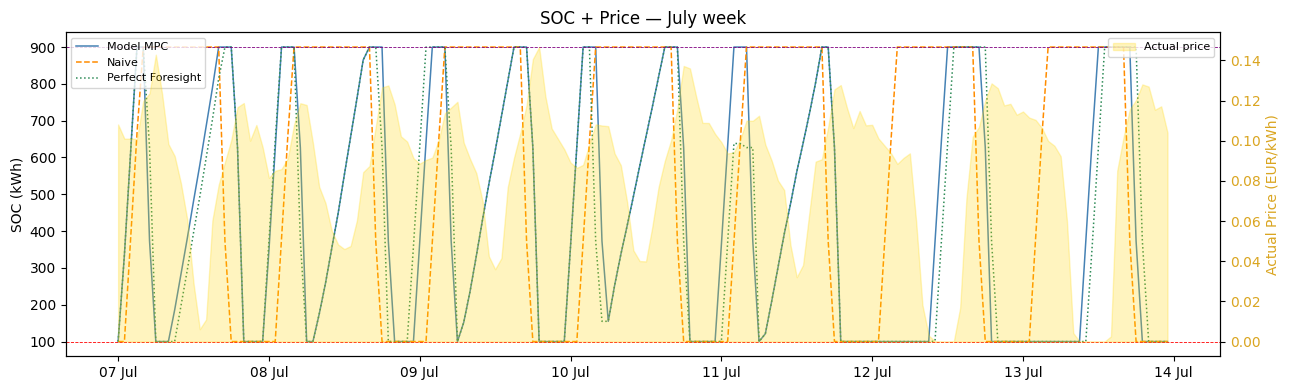

Saved: soc_zoom_september_2025.png


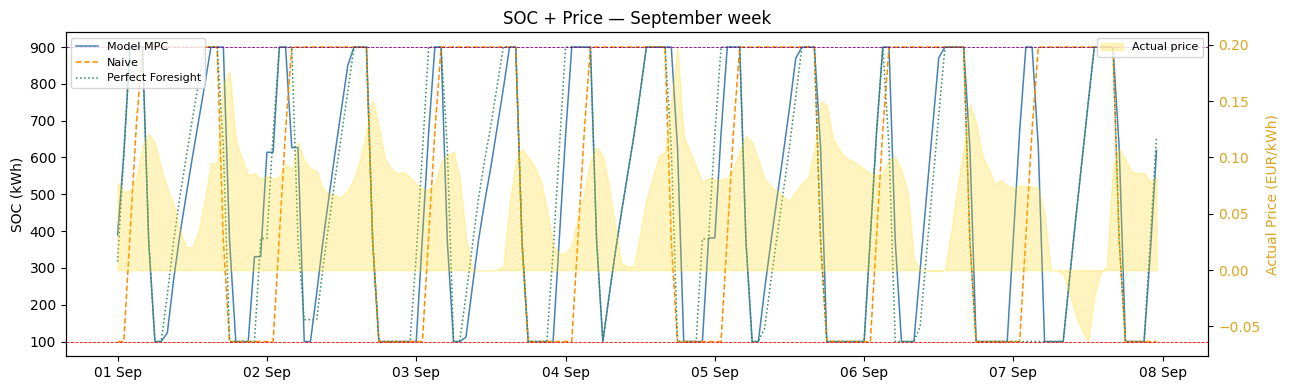

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
for col, label, color in [
    ("soc_model",   "Model MPC",        "steelblue"),
    ("soc_naive",   "Naive",            "darkorange"),
    ("soc_perfect", "Perfect Foresight","seagreen"),
]:
    ax.plot(results.index, results[col], lw=0.6, color=color, label=label)
ax.axhline(SOC_MIN_KWH, color="red",    ls="--", lw=0.7)
ax.axhline(SOC_MAX_KWH, color="purple", ls="--", lw=0.7)
ax.set_ylabel("State of Charge (kWh)")
ax.set_title("Battery SOC — Full Year 2025 (all three strategies)")
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.tight_layout()
for p in [PLOTS_DIR, RESULTS_DIR]:
    plt.savefig(p / "soc_full_year_2025.png", dpi=150, bbox_inches="tight")
print("Saved: soc_full_year_2025.png")
display(fig)
plt.close(fig)

# ── Zoomed views with twin-axis price ─────────────────────────────────────
zoom_windows = [
    ("January 2025",       "2025-01-01", "2025-01-31 23:00"),
    ("July week",          "2025-07-07", "2025-07-13 23:00"),
    ("September week",     "2025-09-01", "2025-09-07 23:00"),
]

for title, start, end in zoom_windows:
    df_z = results.loc[start:end]
    fig, ax1 = plt.subplots(figsize=(13, 4))
    for col, label, color, ls in [
        ("soc_model",   "Model MPC",        "steelblue",  "-"),
        ("soc_naive",   "Naive",            "darkorange", "--"),
        ("soc_perfect", "Perfect Foresight","seagreen",   ":"),
    ]:
        ax1.plot(df_z.index, df_z[col], color=color, lw=1.1, ls=ls, label=label)
    ax1.axhline(SOC_MIN_KWH, color="red",    ls="--", lw=0.6)
    ax1.axhline(SOC_MAX_KWH, color="purple", ls="--", lw=0.6)
    ax1.set_ylabel("SOC (kWh)")
    ax1.set_title(f"SOC + Price — {title}")
    ax1.legend(loc="upper left", fontsize=8)

    ax2 = ax1.twinx()
    ax2.fill_between(df_z.index, 0, df_z["actual_price"],
                     color="gold", alpha=0.25, label="Actual price")
    ax2.set_ylabel("Actual Price (EUR/kWh)", color="goldenrod")
    ax2.tick_params(axis="y", labelcolor="goldenrod")
    ax2.legend(loc="upper right", fontsize=8)

    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax1.xaxis.set_major_locator(mdates.DayLocator())
    plt.tight_layout()
    fname = f"soc_zoom_{title.split()[0].lower()}_2025.png"
    for p in [PLOTS_DIR, RESULTS_DIR]:
        plt.savefig(p / fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")
    display(fig)
    plt.close(fig)

## Section 10 — Grid Import Analysis

The 350 kWh/h grid import limit is a hard constraint in the LP. When building
consumption is high, the battery must discharge to avoid exceeding the limit.
This constraint is regularly binding, especially during peak consumption hours.

Hours at grid limit (≥ 350 kWh/h): 2623 (29.9%)
Hours >90% of limit (> 315 kWh/h): 2751 (31.4%)
Saved: grid_import_analysis_2025.png


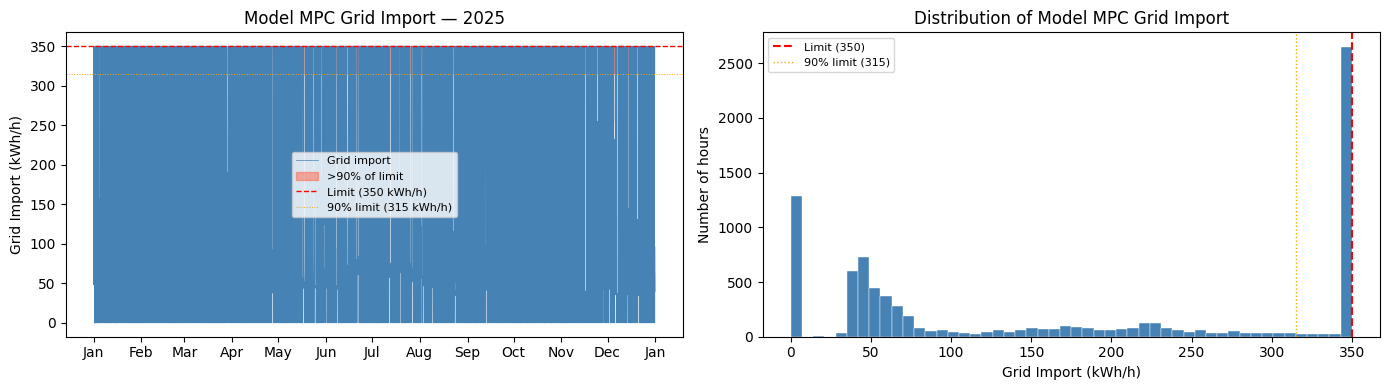

In [10]:
grid_imp = results["grid_import_model"]
limit_90pct = GRID_IMPORT_LIMIT_KWH * 0.9  # 315 kWh/h

hours_at_limit  = (grid_imp >= GRID_IMPORT_LIMIT_KWH - 0.1).sum()
hours_near_limit = (grid_imp > limit_90pct).sum()
print(f"Hours at grid limit (≥ {GRID_IMPORT_LIMIT_KWH:.0f} kWh/h): "
      f"{hours_at_limit} ({hours_at_limit/len(results)*100:.1f}%)")
print(f"Hours >90% of limit (> {limit_90pct:.0f} kWh/h): "
      f"{hours_near_limit} ({hours_near_limit/len(results)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# ── Time series ───────────────────────────────────────────────────────────
ax = axes[0]
near_mask = grid_imp > limit_90pct
ax.plot(results.index, grid_imp, color="steelblue", lw=0.5, label="Grid import")
ax.fill_between(
    results.index, limit_90pct, GRID_IMPORT_LIMIT_KWH,
    where=near_mask, color="tomato", alpha=0.5, label=">90% of limit",
)
ax.axhline(GRID_IMPORT_LIMIT_KWH, color="red", lw=1, ls="--",
           label=f"Limit ({GRID_IMPORT_LIMIT_KWH:.0f} kWh/h)")
ax.axhline(limit_90pct, color="orange", lw=0.7, ls=":",
           label=f"90% limit ({limit_90pct:.0f} kWh/h)")
ax.set_ylabel("Grid Import (kWh/h)")
ax.set_title("Model MPC Grid Import — 2025")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# ── Histogram ─────────────────────────────────────────────────────────────
ax2 = axes[1]
ax2.hist(grid_imp, bins=50, color="steelblue", edgecolor="white", linewidth=0.3)
ax2.axvline(GRID_IMPORT_LIMIT_KWH, color="red", lw=1.5, ls="--",
            label=f"Limit ({GRID_IMPORT_LIMIT_KWH:.0f})")
ax2.axvline(limit_90pct, color="orange", lw=1, ls=":",
            label=f"90% limit ({limit_90pct:.0f})")
ax2.set_xlabel("Grid Import (kWh/h)")
ax2.set_ylabel("Number of hours")
ax2.set_title("Distribution of Model MPC Grid Import")
ax2.legend(fontsize=8)

plt.tight_layout()
for p in [PLOTS_DIR, RESULTS_DIR]:
    plt.savefig(p / "grid_import_analysis_2025.png", dpi=150, bbox_inches="tight")
print("Saved: grid_import_analysis_2025.png")
display(fig)
plt.close(fig)

## Section 11 — Sample Weeks Deep Dive

Three representative weeks show how the battery behaves across different market regimes:

- **January** (winter): Higher and more stable prices driven by gas, limited solar.
  Battery arbitrages morning/evening price differences.
- **May** (spring solar): Midday solar causes price dips (sometimes negative).
  Battery charges during cheap solar hours and discharges in the evening.
- **September** (autumn): Volatility from demand recovery, occasional price spikes.
  Model MPC must handle uncertain price patterns; naive fixed-window strategy misses them.

Saved: week_jan_2025.png


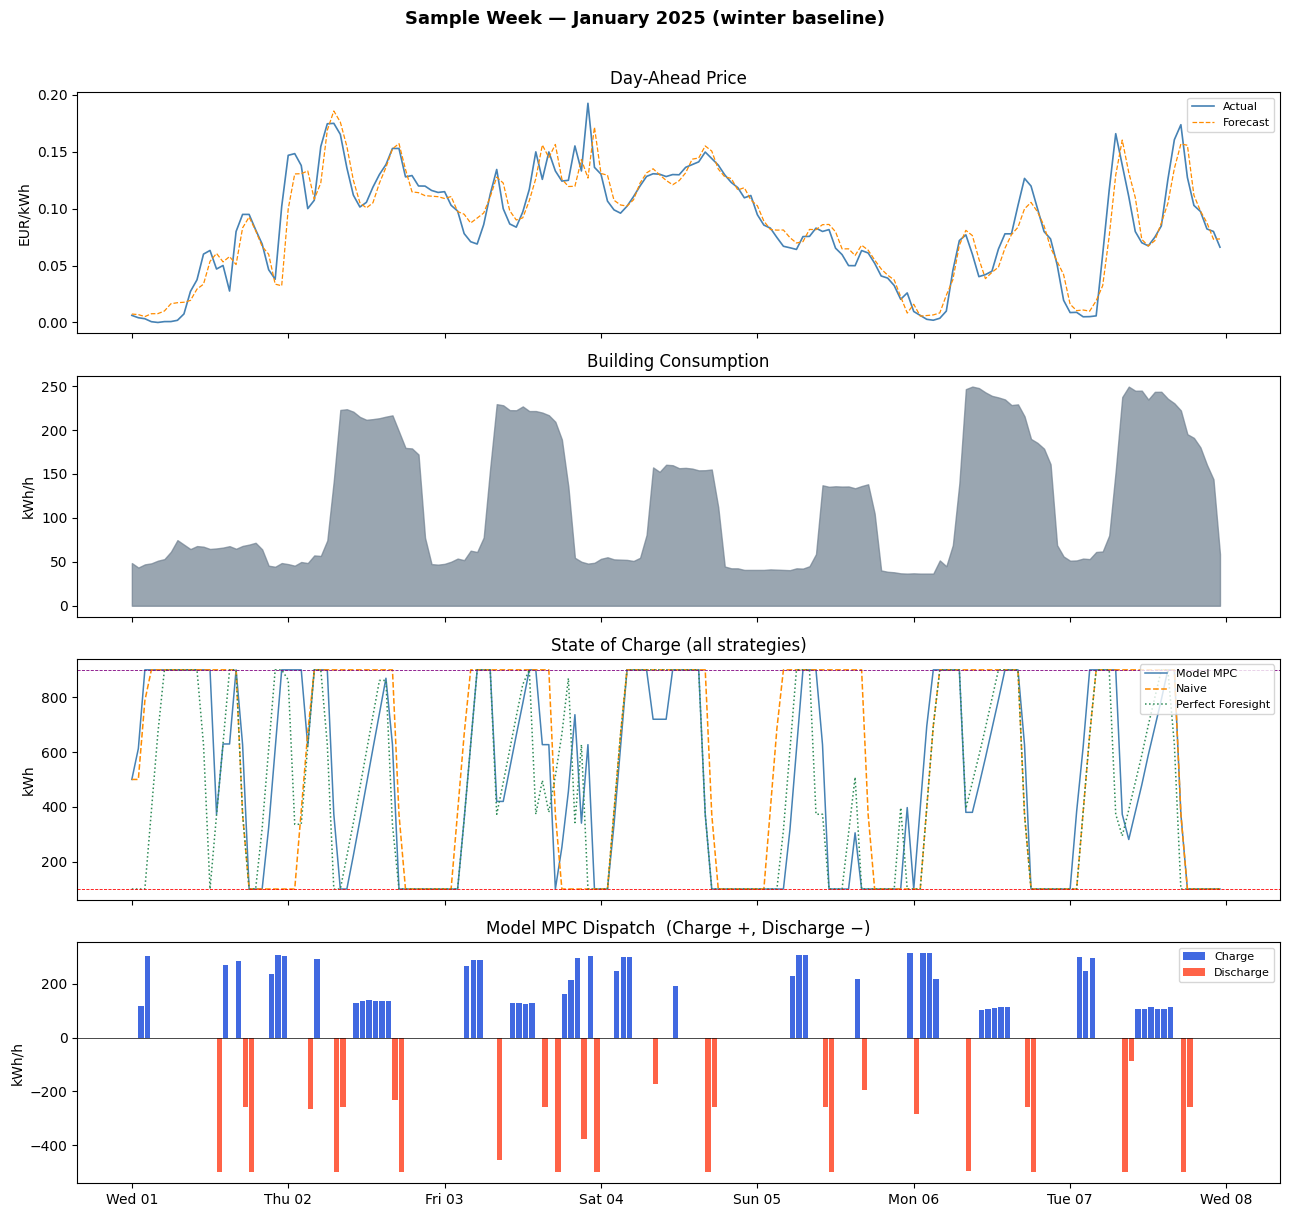

Saved: week_may_2025.png


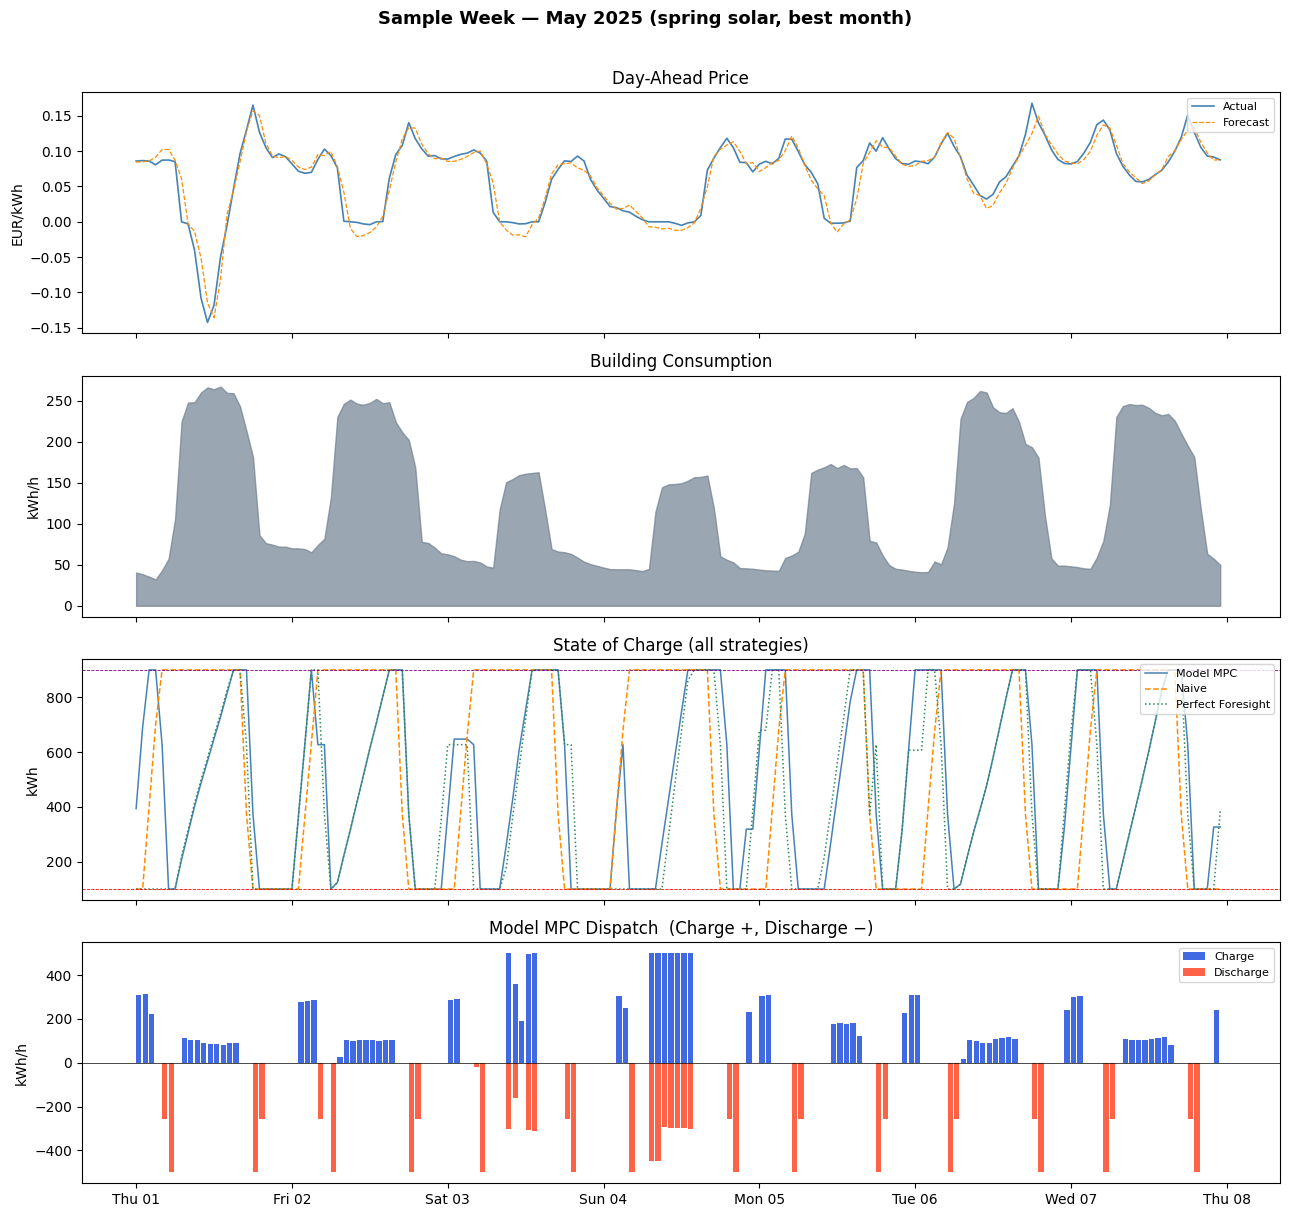

Saved: week_sep_2025.png


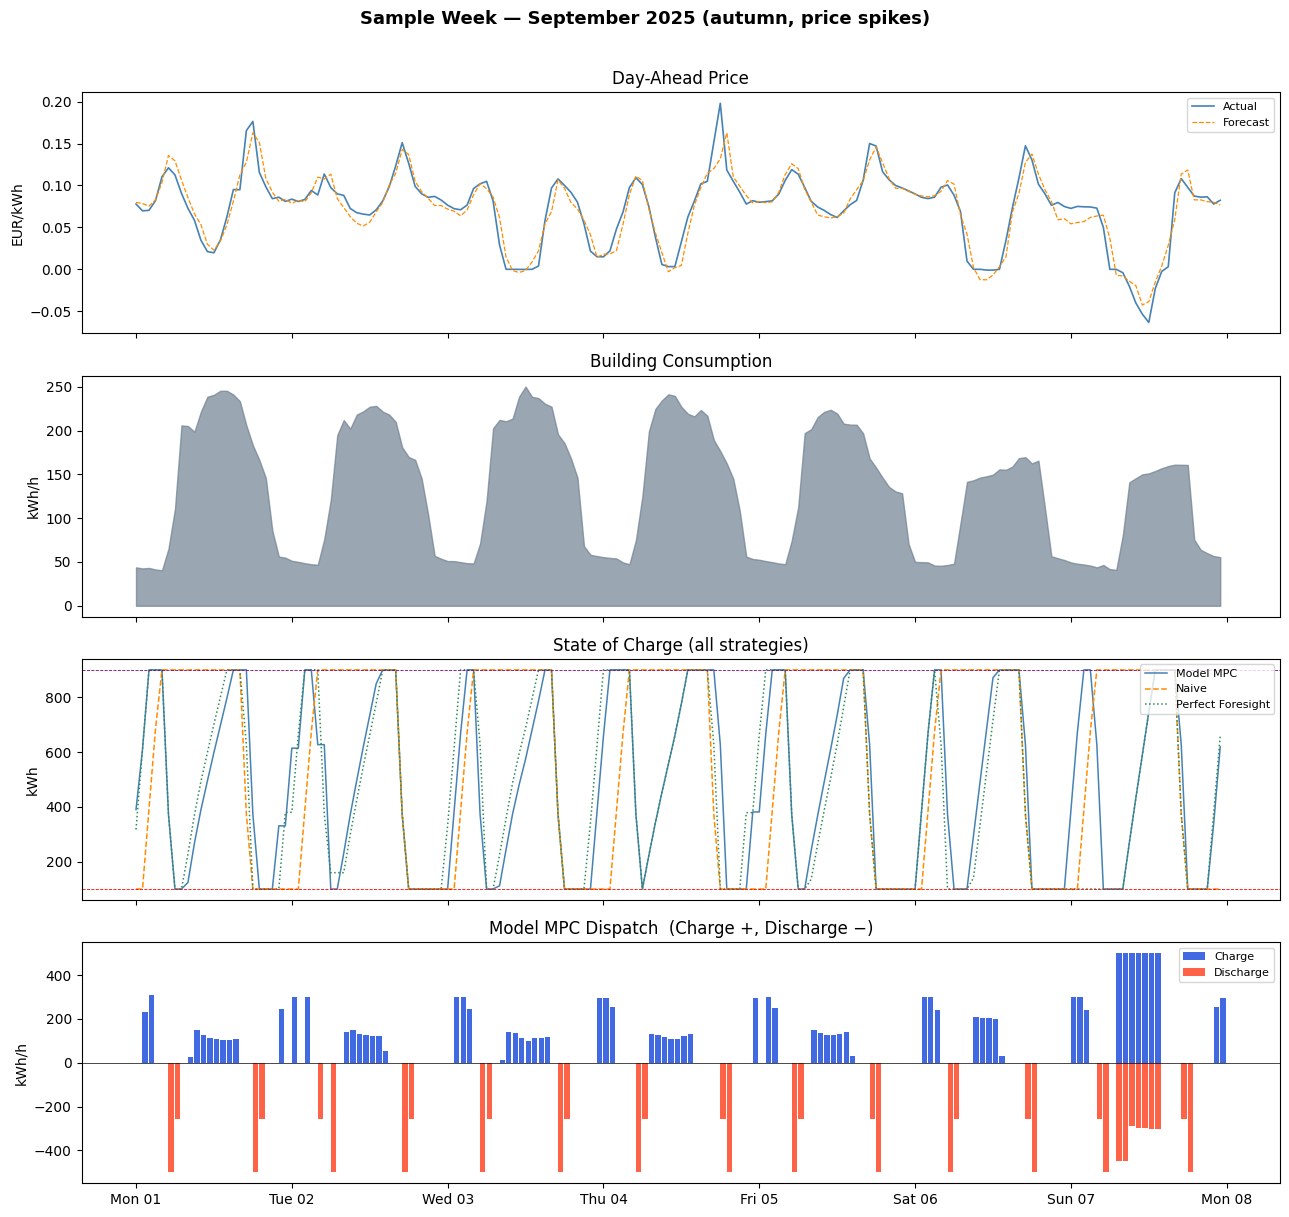

In [11]:
def plot_sample_week(df_w, title, fname):
    fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

    axes[0].plot(df_w.index, df_w["actual_price"],   color="steelblue",  lw=1.2, label="Actual")
    axes[0].plot(df_w.index, df_w["forecast_price"], color="darkorange", lw=0.9, ls="--", label="Forecast")
    axes[0].set_ylabel("EUR/kWh")
    axes[0].set_title(f"Day-Ahead Price")
    axes[0].legend(fontsize=8, loc="upper right")

    axes[1].fill_between(df_w.index, 0, df_w["consumption_kwh"], color="slategray", alpha=0.7)
    axes[1].set_ylabel("kWh/h")
    axes[1].set_title("Building Consumption")

    for col, label, color, ls in [
        ("soc_model",   "Model MPC",        "steelblue",  "-"),
        ("soc_naive",   "Naive",            "darkorange", "--"),
        ("soc_perfect", "Perfect Foresight","seagreen",   ":"),
    ]:
        axes[2].plot(df_w.index, df_w[col], color=color, lw=1.1, ls=ls, label=label)
    axes[2].axhline(SOC_MIN_KWH, color="red",    ls="--", lw=0.6)
    axes[2].axhline(SOC_MAX_KWH, color="purple", ls="--", lw=0.6)
    axes[2].set_ylabel("kWh")
    axes[2].set_title("State of Charge (all strategies)")
    axes[2].legend(fontsize=8, loc="upper right")

    bw = pd.Timedelta(hours=1) * 0.82
    axes[3].bar(df_w.index,  df_w["charge_model"],    width=bw, align="edge", color="royalblue", label="Charge")
    axes[3].bar(df_w.index, -df_w["discharge_model"], width=bw, align="edge", color="tomato",    label="Discharge")
    axes[3].axhline(0, color="black", lw=0.5)
    axes[3].set_ylabel("kWh/h")
    axes[3].set_title("Model MPC Dispatch  (Charge +, Discharge −)")
    axes[3].legend(fontsize=8, loc="upper right")

    axes[3].xaxis.set_major_formatter(mdates.DateFormatter("%a %d"))
    axes[3].xaxis.set_major_locator(mdates.DayLocator())
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    for p in [PLOTS_DIR, RESULTS_DIR]:
        plt.savefig(p / fname, dpi=150, bbox_inches="tight")
    print(f"Saved: {fname}")
    display(fig)
    plt.close(fig)

plot_sample_week(
    results.loc["2025-01-01":"2025-01-07 23:00"],
    "Sample Week — January 2025 (winter baseline)",
    "week_jan_2025.png",
)
plot_sample_week(
    results.loc["2025-05-01":"2025-05-07 23:00"],
    "Sample Week — May 2025 (spring solar, best month)",
    "week_may_2025.png",
)
plot_sample_week(
    results.loc["2025-09-01":"2025-09-07 23:00"],
    "Sample Week — September 2025 (autumn, price spikes)",
    "week_sep_2025.png",
)

## Section 12 — Summary and Conclusions

### What the 89.4% efficiency means

The Model MPC captures **€29,996 out of a theoretical maximum €33,539** — 89.4% of the
perfect foresight value. This is a strong result given that the LightGBM model has
a MAPE of 31.8% on 2025 prices. The key insight is that **directional accuracy matters
more than point accuracy** for battery dispatch: as long as the model correctly identifies
which hours will be cheap vs expensive, the battery can optimise around that signal.
The model achieves 81.3% directional accuracy on 2025, which translates to near-perfect
charge/discharge timing most of the time.

### Why the naive strategy underperforms so dramatically

The naive strategy captures only 35.6% of the perfect foresight value (€11,943 vs €33,539).
The fixed 02–05/17–20 UTC windows were designed for the traditional residential demand
pattern. However:
1. **Solar-rich days** push prices to zero or negative at midday, not just overnight —
   the naive strategy misses the midday charging opportunity entirely.
2. **Gas price volatility** creates irregular price spikes that don't align with the
   fixed schedule.
3. **Grid import headroom** at 02–05 UTC is sometimes limited by high overnight
   consumption, preventing full charging.

### What the grid constraint means in practice

31.4% of hours operate within 10% of the 350 kWh/h grid limit. This means the battery
is actively constrained a third of the time — not just providing arbitrage value but
physically protecting the building from grid connection overloads. A larger grid
connection would unlock additional savings.

### What would improve results

1. **Better forecasts** — incorporating real-time gas futures prices, which are the
   primary driver of Dutch day-ahead prices, would reduce MAPE and improve dispatch
   decisions.
2. **Longer look-ahead** — extending from 24h to 48h would help with weekend/weekday
   pattern shifts.
3. **Quantile-aware dispatch** — using the p10/p90 intervals to hedge uncertain price
   periods (already trained, not yet used in the optimizer).
4. **More granular consumption data** — the 2025 building data is well-aligned; adding
   2021–2024 historical consumption would enable richer consumption features in the
   LightGBM model.

In [12]:
# Final summary table
total_m = results["revenue_model"].sum()
total_n = results["revenue_naive"].sum()
total_p = results["revenue_perfect"].sum()
cycles_m = results["discharge_model"].sum() / CAPACITY_KWH
cycles_n = results["discharge_naive"].sum() / CAPACITY_KWH
cycles_p = results["discharge_perfect"].sum() / CAPACITY_KWH
n_days = len(results) / 24
peak_import = results["grid_import_model"].max()
near_limit = int((results["grid_import_model"] > GRID_IMPORT_LIMIT_KWH * 0.9).sum())

sep = "=" * 68
print(sep)
print("FINAL BACKTEST SUMMARY — 2025")
print("Revenue = savings vs paying market price for 100% of consumption from grid")
print(sep)
print(f"\n{'Metric':<34} {'Model MPC':>12} {'Naive':>10} {'Perfect':>10}")
print("─" * 68)
print(f"{'Total savings (EUR)':<34} {total_m:>12.2f} {total_n:>10.2f} {total_p:>10.2f}")
print(f"{'Avg daily savings (EUR/day)':<34} {total_m/n_days:>12.2f} {total_n/n_days:>10.2f} {total_p/n_days:>10.2f}")
print(f"{'Full cycles (discharge / capacity)':<34} {cycles_m:>12.1f} {cycles_n:>10.1f} {cycles_p:>10.1f}")
print(f"{'% of perfect foresight captured':<34} {total_m/total_p*100:>11.1f}% {total_n/total_p*100:>9.1f}%    100.0%")
print("─" * 68)
print(f"\n{'Peak grid import (kWh/h)':<44} {peak_import:>6.1f}  (limit: {GRID_IMPORT_LIMIT_KWH:.0f})")
print(f"{'Hours >90% of grid limit':<44} {near_limit:>6d}  ({near_limit/len(results)*100:.1f}% of hours)")
print(sep)
print("\nPart 1 complete. Part 2 (live real-time system) is a separate repository.")

FINAL BACKTEST SUMMARY — 2025
Revenue = savings vs paying market price for 100% of consumption from grid

Metric                                Model MPC      Naive    Perfect
────────────────────────────────────────────────────────────────────
Total savings (EUR)                    29995.97   11942.78   33539.26
Avg daily savings (EUR/day)               82.19      32.72      91.90
Full cycles (discharge / capacity)        564.5      276.8      526.0
% of perfect foresight captured           89.4%      35.6%    100.0%
────────────────────────────────────────────────────────────────────

Peak grid import (kWh/h)                      350.0  (limit: 350)
Hours >90% of grid limit                       2751  (31.4% of hours)

Part 1 complete. Part 2 (live real-time system) is a separate repository.
